<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 82 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">A/B Testing &amp; Online Experiments 🧪</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">A/B testing is everything in this Part wired into one workflow: randomize, power the test, analyze the primary rate with statsmodels' two-proportion z and a lift CI, watch the guardrails, and never peek. We run a real landing-page experiment end to end.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(82)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · DECIDE n BEFORE YOU LAUNCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Power analysis comes first</div>
<div style="color:#4a5578;margin-top:6px">The cardinal rule of experimentation: choose the sample size BEFORE collecting data, from a power analysis. You specify the baseline rate, the smallest lift worth detecting (the MDE), alpha, and target power (usually 80%), and solve for n per arm.</div>
</div>

In [2]:
from scipy.stats import norm
def n_per_arm(p1, p2, alpha=0.05, power=0.80):
    za=norm.ppf(1-alpha/2); zb=norm.ppf(power)
    pbar=(p1+p2)/2
    return ((za*np.sqrt(2*pbar*(1-pbar)) + zb*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2)/(p2-p1)**2
base=0.118
for mde in [0.01, 0.02, 0.03]:
    n=n_per_arm(base, base+mde)
    print(f"baseline {base:.0%}, detect +{mde*100:.0f}pts -> need ~{int(np.ceil(n)):,} per arm")
print("\nSmaller lifts need dramatically larger samples (n grows like 1/MDE^2).")

baseline 12%, detect +1pts -> need ~16,933 per arm
baseline 12%, detect +2pts -> need ~4,380 per arm
baseline 12%, detect +3pts -> need ~2,011 per arm

Smaller lifts need dramatically larger samples (n grows like 1/MDE^2).


Deciding n in advance is what makes the 5% false-positive rate and the 80% power real. Picking the sample size after peeking at results, or stopping as soon as things look good, quietly destroys both guarantees. The minimum detectable effect drives everything: halving the lift you want to catch roughly quadruples the sample.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE PRIMARY METRIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two-proportion z-test plus a confidence interval on the lift</div>
<div style="color:#4a5578;margin-top:6px">An A/B test's primary metric is usually a conversion RATE, so the analysis is the two-proportion z-test, paired with a confidence interval for the lift. statsmodels gives both in one line each, no manual pooled standard error.</div>
</div>

In [3]:
cA,nA = 472,4000; cB,nB = 572,4000        # illustrative converts
z, p = proportions_ztest([cB, cA], [nB, nA])              # the test (pooled SE)
lo, hi = confint_proportions_2indep(cB, nB, cA, nA, method="wald")   # CI for the lift
pA,pB = cA/nA, cB/nB
print(f"A={pA:.3%}, B={pB:.3%}, lift={pB-pA:+.3%}")
print(f"z={z:.2f}, p={p:.4f}, 95% CI for lift [{lo*100:+.3f}, {hi*100:+.3f}] pts")
print("-> ship B: lift CI excludes 0" if lo>0 else "-> inconclusive: CI includes 0")

A=11.800%, B=14.300%, lift=+2.500%
z=3.32, p=0.0009, 95% CI for lift [+1.025, +3.975] pts
-> ship B: lift CI excludes 0


Reporting the <strong>confidence interval for the lift</strong>, not just the p-value, is what turns a test into a business decision: it shows both that the effect is real and how big it plausibly is. A lift that is significant but trivially small may not be worth the engineering cost of shipping.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · THE PEEKING TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why you cannot stop the moment p < 0.05</div>
<div style="color:#4a5578;margin-top:6px">Checking results repeatedly and stopping as soon as p < 0.05 ('peeking') massively inflates the false-positive rate, because you give yourself many chances to cross the line by luck. We simulate an A/A test (no real difference) and peek 20 times.</div>
</div>

In [4]:
def peek_false_positive(checks=20, nmax=8000):
    a=rng.random(nmax)<0.12; b=rng.random(nmax)<0.12   # SAME true rate -> H0 true
    for n in np.linspace(nmax//checks, nmax, checks).astype(int):
        ca,cb=a[:n].sum(),b[:n].sum()
        if 0 in (ca,cb): continue
        if proportions_ztest([cb,ca],[n,n])[1] < 0.05: return True   # stopped early on a fluke
    return False
rate=np.mean([peek_false_positive() for _ in range(1500)])
print(f"A/A test (NO real difference), peeking 20 times: false-positive rate = {rate:.2f}")
print("Far above 0.05! Fix: set n in advance, or use sequential / always-valid methods.")

A/A test (NO real difference), peeking 20 times: false-positive rate = 0.25
Far above 0.05! Fix: set n in advance, or use sequential / always-valid methods.


Peeking turns a 5% test into something far leakier, here roughly a quarter of A/A tests "win" by chance. The disciplined fixes: fix the sample size up front and analyze once, or adopt proper sequential methods (alpha-spending, always-valid p-values) designed for continuous monitoring.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · A LANDING-PAGE EXPERIMENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Conversion, revenue, and the ship decision</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A team ran a randomized A/B test on a new landing page (`ch82_online_experiment.xlsx`), 4,200 sessions. Variant A is the control, B the new design. We explore the data first, then analyze the primary metric (conversion) with statsmodels and the secondary metric (revenue per session).

In [5]:
try:    e = pd.read_excel("../../data/ch82_online_experiment.xlsx", sheet_name="Sessions")
except FileNotFoundError: e = pd.read_excel(BASE+"ch82_online_experiment.xlsx", sheet_name="Sessions")
# EXPLORE FIRST: size, missing, per-arm summary, and a randomization (device-mix) check
print("shape:", e.shape, "| missing:", e.isna().sum().sum())
print(e.groupby("variant").agg(n=("converted","size"), conv=("converted","sum"),
                               rate=("converted","mean"), rev=("revenue","mean")).round(4))
print("\ndevice mix by variant (should be balanced):")
print(pd.crosstab(e.variant, e.device, normalize="index").round(3))

shape: (4200, 7) | missing: 0
            n  conv    rate     rev
variant                            
A        2064   227  0.1100  5.9550
B        2136   283  0.1325  7.3422

device mix by variant (should be balanced):
device   desktop  mobile  tablet
variant                         
A          0.317   0.618   0.065
B          0.334   0.590   0.076


[PRIMARY] conversion A=11.00% vs B=13.25%, lift=+2.25pts
          z=2.23, p=0.0256, 95% CI for lift [+0.28, +4.22] pts
          -> SHIP B (lift CI excludes 0)
[SECONDARY] revenue/session A=5.95 vs B=7.34, Welch t=2.38, p=0.0171


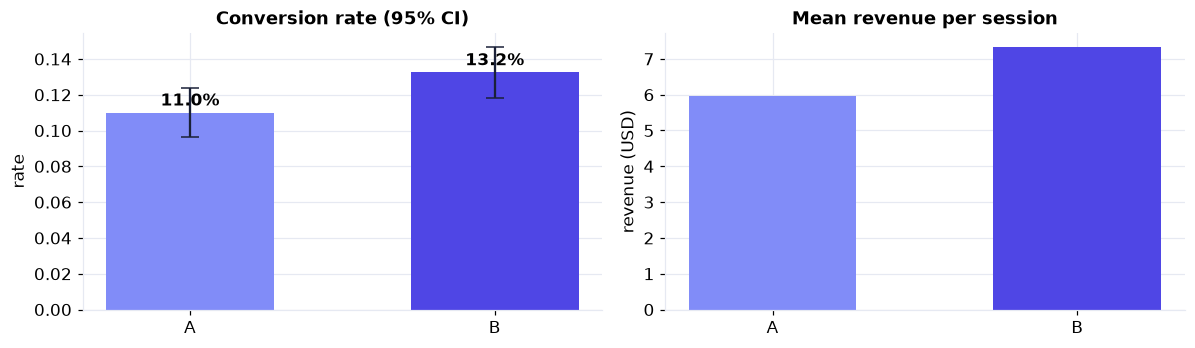

In [6]:
A=e[e.variant=="A"]; B=e[e.variant=="B"]
nA,nB=len(A),len(B); cA,cB=A.converted.sum(),B.converted.sum()
pA,pB=cA/nA,cB/nB
# PRIMARY metric: two-proportion z-test + lift CI (statsmodels)
z,p = proportions_ztest([cB,cA],[nB,nA])
lo,hi = confint_proportions_2indep(cB,nB,cA,nA,method="wald")
print(f"[PRIMARY] conversion A={pA:.2%} vs B={pB:.2%}, lift={(pB-pA)*100:+.2f}pts")
print(f"          z={z:.2f}, p={p:.4f}, 95% CI for lift [{lo*100:+.2f}, {hi*100:+.2f}] pts")
print("          -> SHIP B (lift CI excludes 0)" if lo>0 else "          -> inconclusive")
# SECONDARY metric: revenue per session (numeric) -> Welch t-test
tt=stats.ttest_ind(B.revenue, A.revenue, equal_var=False)
print(f"[SECONDARY] revenue/session A={A.revenue.mean():.2f} vs B={B.revenue.mean():.2f}, Welch t={tt.statistic:.2f}, p={tt.pvalue:.4f}")
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].bar(["A","B"],[pA,pB],color=[LIGHT,IND],width=0.55)
ax[0].errorbar([0,1],[pA,pB],yerr=[1.96*np.sqrt(pA*(1-pA)/nA),1.96*np.sqrt(pB*(1-pB)/nB)],fmt="none",ecolor=INK,capsize=6)
ax[0].set_title("Conversion rate (95% CI)"); ax[0].set_ylabel("rate")
for i,v in enumerate([pA,pB]): ax[0].text(i,v+0.004,f"{v:.1%}",ha="center",fontweight="bold")
ax[1].bar(["A","B"],[A.revenue.mean(),B.revenue.mean()],color=[LIGHT,IND],width=0.55)
ax[1].set_title("Mean revenue per session"); ax[1].set_ylabel("revenue (USD)")
plt.tight_layout(); plt.show()

The verdict is to <strong>ship B</strong>. Conversion rises from about 11.0% to 13.3%, a lift of roughly <strong>+2.25 points</strong> whose 95% interval (about +0.3 to +4.2 points) sits entirely above zero (z = 2.23, p &#8776; 0.026). Revenue per session also climbs (about 5.95 to 7.34 dollars, Welch p &#8776; 0.017), so the conversion win is not cannibalizing order value. Both metrics agree, and because n was fixed in advance, the 5% guarantee is intact, this is a clean, shippable result.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ A/B testing, and the end of Part XII</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">An A/B test is the whole Part in one workflow: randomize, fix n via a power analysis, analyze the primary rate with statsmodels&#39; two-proportion z-test plus a lift CI, check guardrail metrics, and never peek without correction. On a real experiment, B lifts conversion +2.25 points (95% CI +0.3 to +4.2, p &#8776; 0.026) and revenue too, so ship it. This closes Part XII: you can now state a hypothesis, choose the right test, weigh both error types, and turn data into a defensible decision.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>